In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
method_list= ["CCGL", "CCGM", "CCGM2"]
budget_list = [3,6,9]
scale_list = [2]
seed_list = [i for i in range(1,11)]
time_limit = 3600

In [22]:
df = dict()
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            for seed in seed_list:
                timehorizon = 21*scale
                csv_path = f"Rostering/{seed}_{timehorizon}_{method}_{budget}_{time_limit}.csv"
                df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                # print(f"Method: {method}, Budget: {budget}, Scale: {scale}, Seed: {seed}")
                # print(df_csv.head())
                df[(method, budget, scale, seed)] = df_csv

In [23]:
time_dict = dict()
gap_list = dict()
time_worst_case = dict()
outer_iter = dict()
inner_iter = dict()
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            for seed in seed_list:
                time_dict[(method, budget, scale, seed)] = float(df[(method, budget, scale, seed)].iloc[3,1])
                gap_list[(method, budget, scale, seed)] = float(df[(method, budget, scale, seed)].iloc[6,1])
                time_worst_case[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,1]]
                outer_iter[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,2]]
                inner_iter[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,3]]

In [24]:
instance_solved = dict()
average_time = dict()
average_gap = dict()
average_nb_worstcase = dict()
average_time_worstcase = dict()
nb_average_inner_iter = dict()
K=300
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            instance_solved[(method, budget, scale)] = sum([1 for seed in seed_list if time_dict[(method, budget, scale, seed)] < time_limit-1])
            average_time[(method, budget, scale)] = sum([time_dict[(method, budget, scale, seed)] for seed in seed_list if time_dict[(method, budget, scale, seed)] < time_limit-1]) / instance_solved[(method, budget, scale)] if instance_solved[(method, budget, scale)] > 0 else 0
            average_gap[(method, budget, scale)] = sum([gap_list[(method, budget, scale, seed)] for seed in seed_list if time_dict[(method, budget, scale, seed)] >= time_limit-1]) / (10-instance_solved[(method, budget, scale)]) if instance_solved[(method, budget, scale)] < 10 else 0
            average_nb_worstcase[(method, budget, scale)] = sum([len(time_worst_case[(method, budget, scale, seed)]) for seed in seed_list]) / 10


            average_time_worstcase[(method, budget, scale)] = [sum([t for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k]) / (1e-10 + sum([1 for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k])) for k in range(K)]
            nb_average_inner_iter[(method, budget, scale)] = [sum([1 for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k]) for k in range(K)]

In [26]:
# Créer un DataFrame avec tous les résultats
results_data = []

for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            results_data.append({
                'method': method,
                'budget_scale': (budget, 21*scale),
                'solved': f"{instance_solved[(method, budget, scale)]}/10",
                'average_time': round(average_time[(method, budget, scale)], 2),
                'average_gap': round(average_gap[(method, budget, scale)], 2),
                'average_nb_worst_case': round(average_nb_worstcase[(method, budget, scale)], 2)
            })

# Créer le DataFrame et l'exporter en CSV
results_df = pd.DataFrame(results_data)
results_df.to_csv('results_2.csv', index=False)
print(results_df)


  method budget_scale solved  average_time  average_gap  average_nb_worst_case
0   CCGL      (3, 42)   2/10        894.56         1.93                  194.1
1   CCGL      (6, 42)   0/10          0.00         4.29                  145.8
2   CCGL      (9, 42)   0/10          0.00         5.98                  119.4
3   CCGM      (3, 42)   1/10       1720.91         2.28                  118.0
4   CCGM      (6, 42)   0/10          0.00         5.99                   55.9
5   CCGM      (9, 42)   0/10          0.00         8.33                   34.4
6  CCGM2      (3, 42)   2/10        939.12         1.88                  207.2
7  CCGM2      (6, 42)   0/10          0.00         4.24                  149.9
8  CCGM2      (9, 42)   0/10          0.00         5.93                  122.3


In [45]:
average_nb_worstcase

{('CCGL', 3, 1): 0.0,
 ('CCGL', 6, 1): 0.0,
 ('CCGL', 9, 1): 0.0,
 ('CCGM', 3, 1): 0.0,
 ('CCGM', 6, 1): 0.0,
 ('CCGM', 9, 1): 0.0}

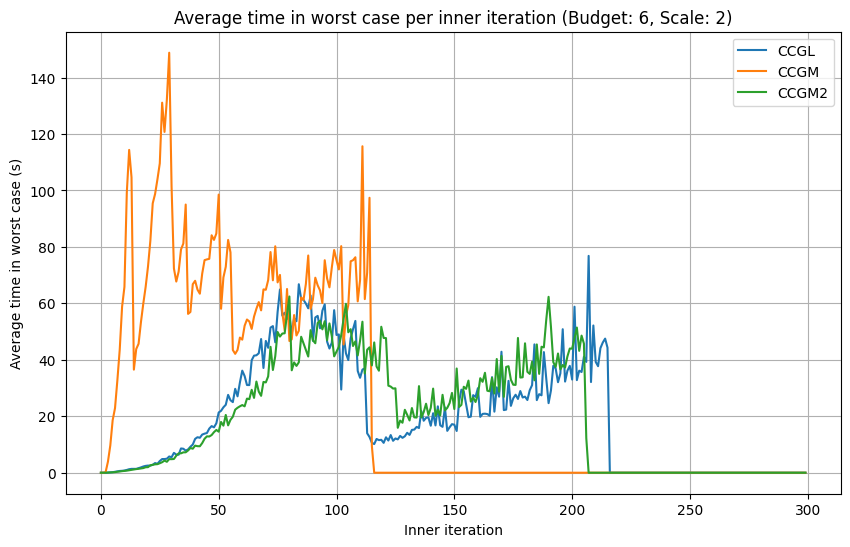

In [13]:
budget = 6
scale = 2
plt.figure(figsize=(10,6))
for method in method_list:
    plt.plot(range(K), average_time_worstcase[(method, budget, scale)], label=method)
plt.xlabel("Inner iteration")
plt.ylabel("Average time in worst case (s)")
plt.title(f"Average time in worst case per inner iteration (Budget: {budget}, Scale: {scale})")
plt.legend()
plt.grid()
# plt.savefig(f"time_comparison_rostering_{budget}.pdf")

In [14]:
method_list= ["CCGL", "CCGM", "CCGM2"]
budget_list = [1,2,3]
size_list = [1,2,3]
time_limit = 3600

In [15]:
df = dict()
for method in method_list:
    for budget in budget_list:
        for size in size_list:
            if size == 1:
                name = "IEEE3"
            elif size == 2:
                name = "IEEE12"
            elif size == 3:
                name = "IEEE54"
            csv_path = f"UC/{name}_{method}_{budget}_{time_limit}.csv"
            df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
            # print(f"Method: {method}, Budget: {budget}, Scale: {scale}, Seed: {seed}")
            # print(df_csv.head())
            df[(method, budget, size)] = df_csv

In [16]:
time_dict = dict()
gap_list = dict()
time_worst_case = dict()
outer_iter = dict()
inner_iter = dict()
for method in method_list:
    for budget in budget_list:
        for size in size_list:
                time_dict[(method, budget, size)] = float(df[(method, budget, size)].iloc[3,1])
                gap_list[(method, budget, size)] = float(df[(method, budget, size)].iloc[6,1])
                time_worst_case[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,1]]
                outer_iter[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,2]]
                inner_iter[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,3]]

In [17]:
instance_solved = dict()
average_time = dict()
average_gap = dict()
average_nb_worstcase = dict()
average_time_worstcase = dict()
nb_average_inner_iter = dict()
K=50
for method in method_list:
    for budget in budget_list:
        for size in size_list:
            instance_solved[(method, budget, size)] = 1 if time_dict[(method, budget, size)] < time_limit - 1 else 0
            average_time[(method, budget, size)] = time_dict[(method, budget, size)]
            average_gap[(method, budget, size)] = gap_list[(method, budget, size)]
            average_nb_worstcase[(method, budget, size)] = sum([len(time_worst_case[(method, budget, size)])])


            average_time_worstcase[(method, budget, size)] = [sum([t for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k]) / (1e-10 + sum([1 for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k])) for k in range(K)]
            nb_average_inner_iter[(method, budget, size)] = [sum([1 for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k]) for k in range(K)]

In [18]:
# Créer un DataFrame avec tous les résultats
results_data = []

for method in method_list:
    for budget in budget_list:
        for size in size_list:
            results_data.append({
                'method': method,
                'size' : size,
                'budget_scale': budget,
                'solved': f"{instance_solved[(method, budget, size)]}/1",
                'average_time': round(average_time[(method, budget, size)], 2),
                'average_gap': round(average_gap[(method, budget, size)], 2),
                'average_nb_worst_case': round(average_nb_worstcase[(method, budget, size)], 2)
            })

# Créer le DataFrame et l'exporter en CSV
results_df = pd.DataFrame(results_data)
# results_df.to_csv('results_UC.csv', index=False)
print(results_df)

   method  size  budget_scale solved  average_time  average_gap  \
0    CCGL     1             1    1/1         21.10         0.17   
1    CCGL     2             1    0/1       3864.24         1.26   
2    CCGL     3             1    0/1       3681.94         2.95   
3    CCGL     1             2    0/1       3602.28         0.69   
4    CCGL     2             2    0/1       3625.97         7.34   
5    CCGL     3             2    0/1       3780.09        11.67   
6    CCGL     1             3    0/1       3627.02         3.81   
7    CCGL     2             3    0/1       3613.00        12.44   
8    CCGL     3             3    0/1       3832.43        20.08   
9    CCGM     1             1    1/1         20.37         0.16   
10   CCGM     2             1    0/1       3838.65         1.26   
11   CCGM     3             1    0/1       3735.13         6.83   
12   CCGM     1             2    0/1       3612.03         1.18   
13   CCGM     2             2    0/1       3709.52         8.7

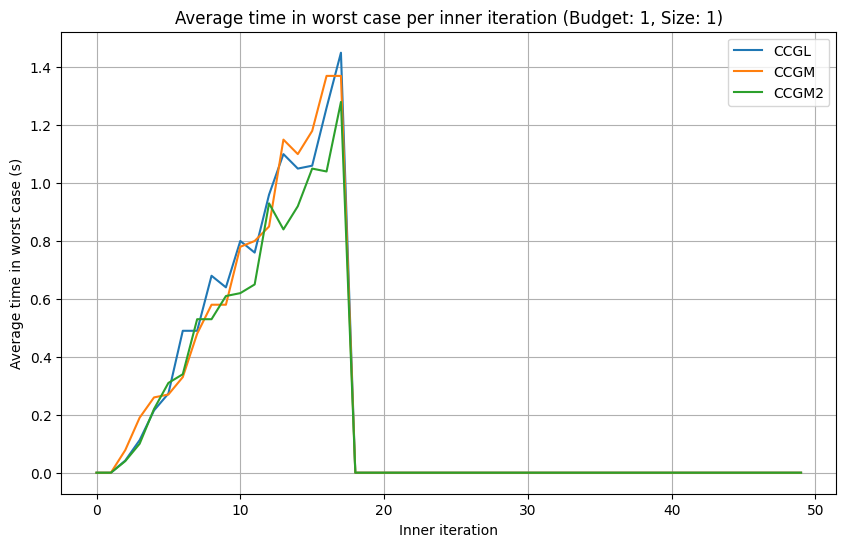

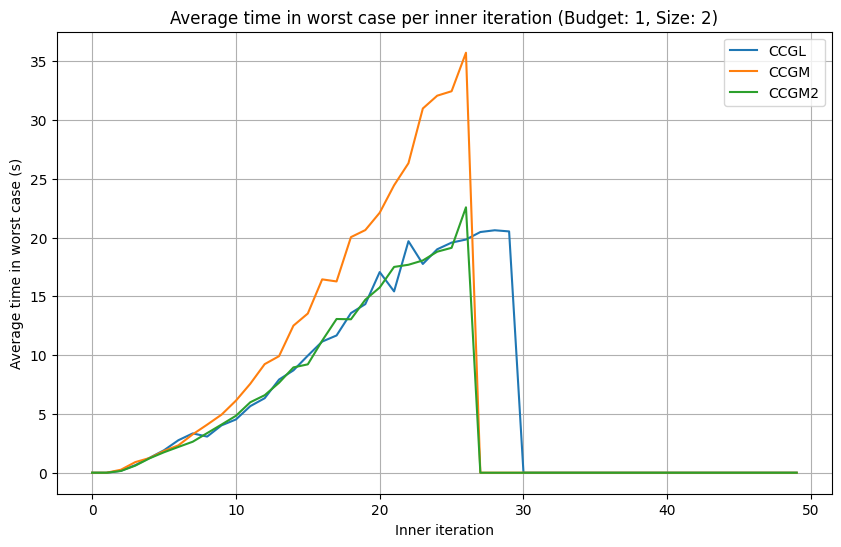

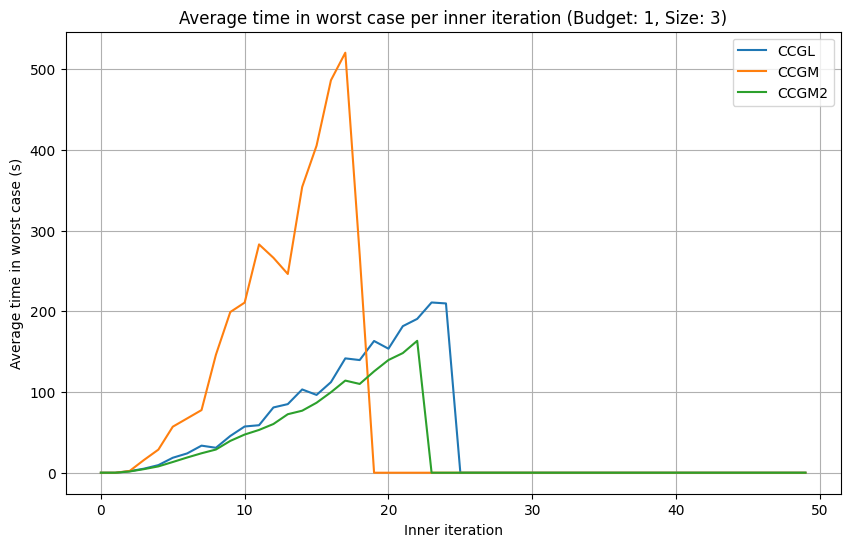

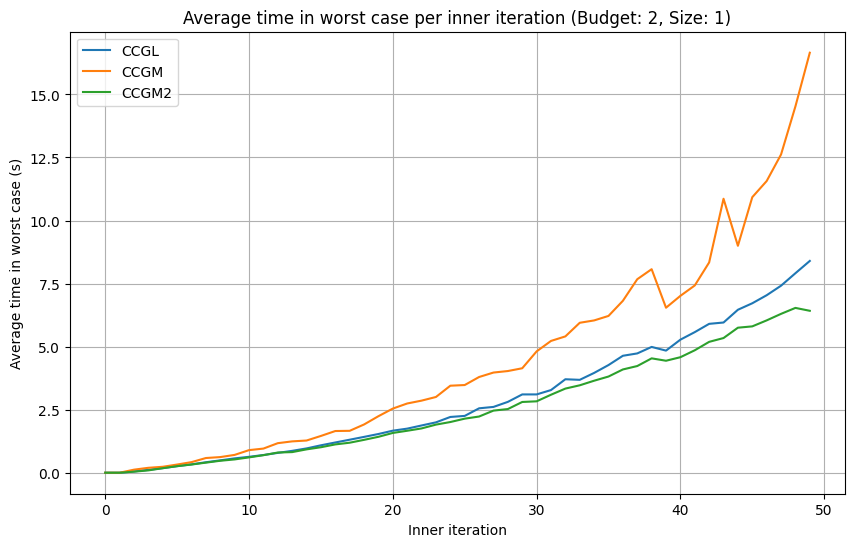

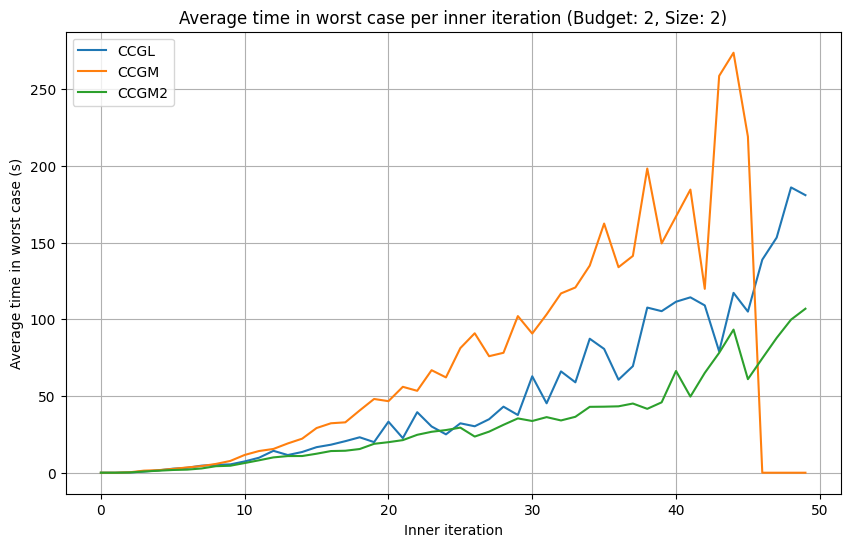

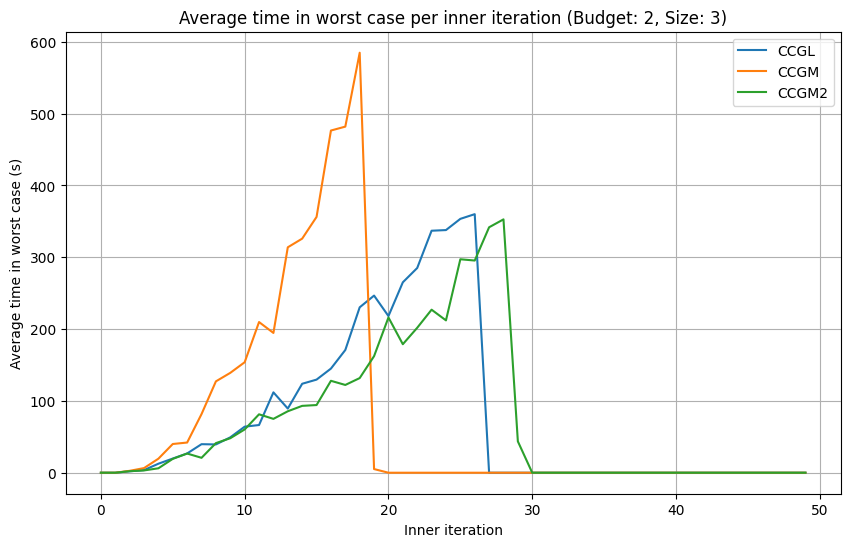

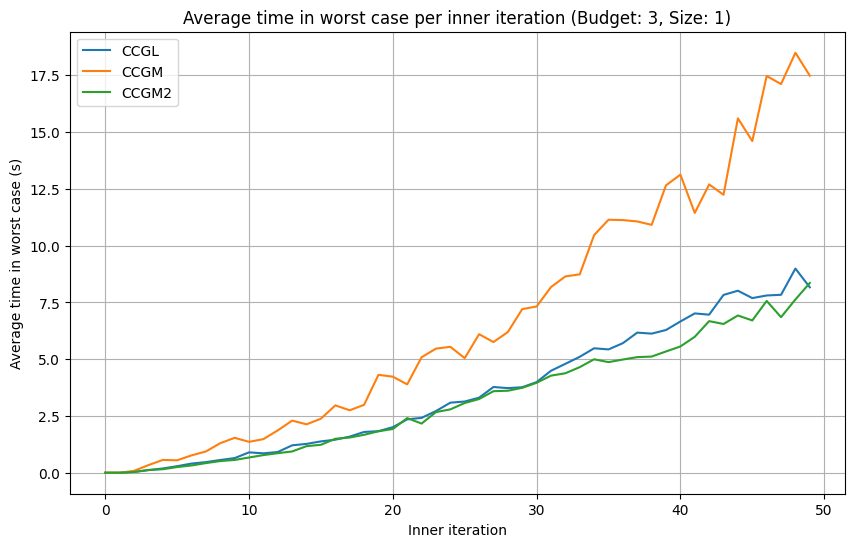

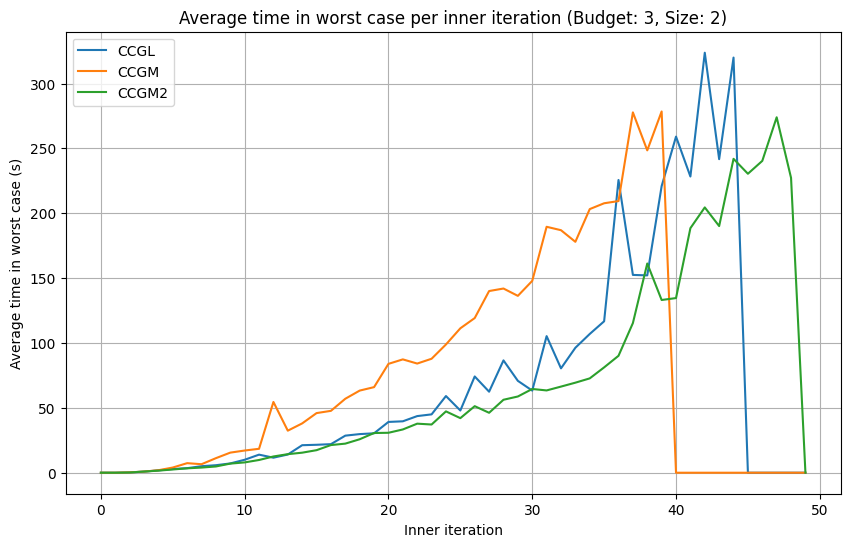

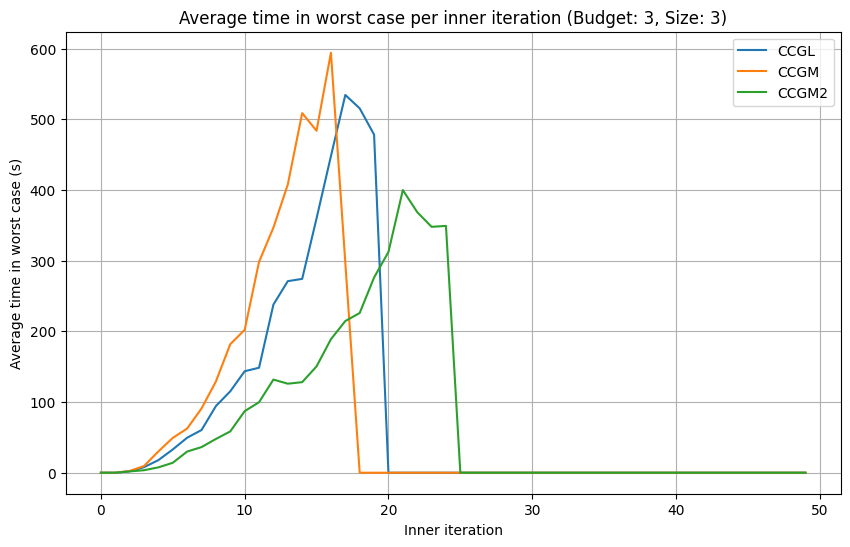

In [19]:
for budget in budget_list:
    for size in size_list:
        plt.figure(figsize=(10,6))
        for method in method_list:
            plt.plot(range(K), average_time_worstcase[(method, budget, size)], label=method)
        plt.xlabel("Inner iteration")
        plt.ylabel("Average time in worst case (s)")
        plt.title(f"Average time in worst case per inner iteration (Budget: {budget}, Size: {size})")
        plt.legend()
        plt.grid()
        # plt.savefig(f"time_comparison_UC_{size}_{budget}.pdf")